In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA


In [2]:
df=pd.read_csv('EastWestAirlines1.csv')

In [3]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [4]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [5]:
import numpy as np

In [6]:
df_numeric = df.select_dtypes(include=np.number)


In [7]:
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

df_no_outliers = df_numeric[~((df_numeric < (Q1 - 1.5 * IQR)) | 
                              (df_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]


In [8]:
df_no_outliers.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
5,6,16420,0,1,1,1,0,0,0,0,6942,0


In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_no_outliers)


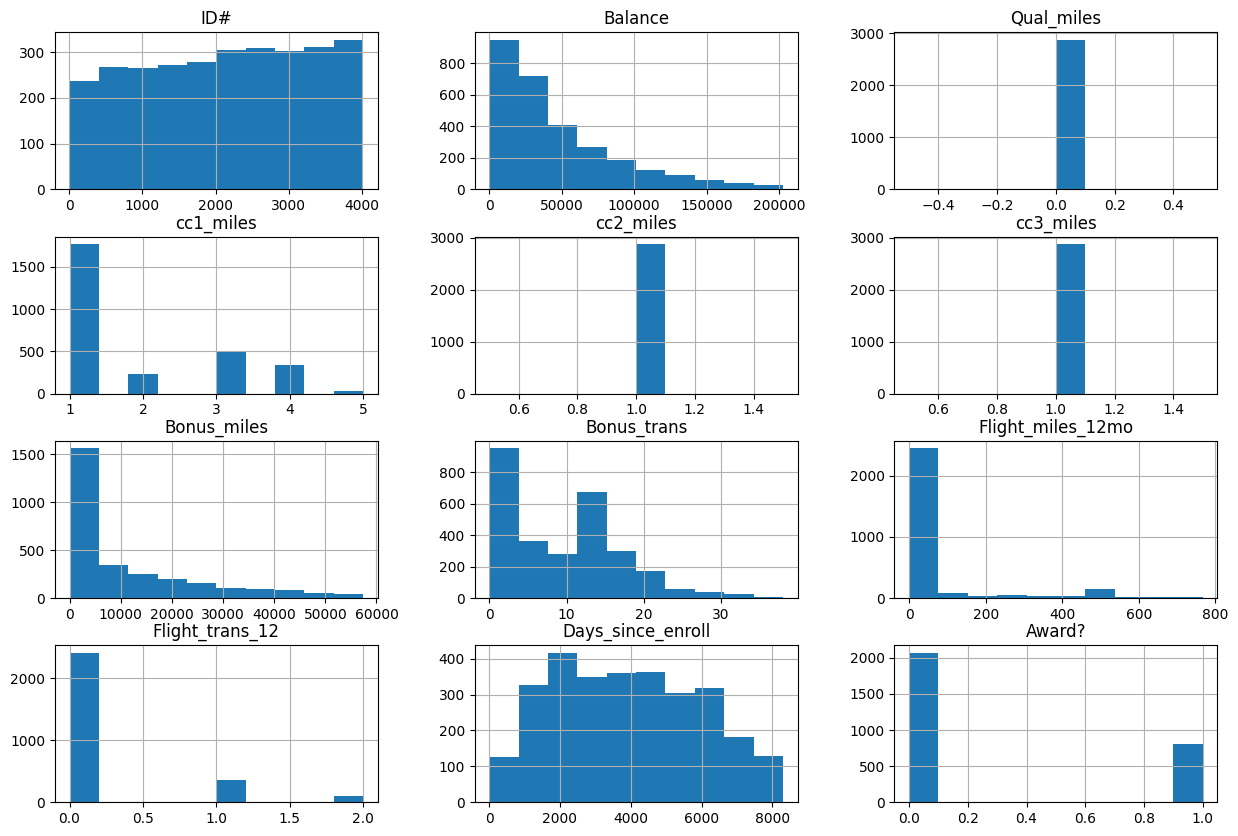

In [11]:
df_no_outliers.hist(figsize=(15,10))
plt.show()


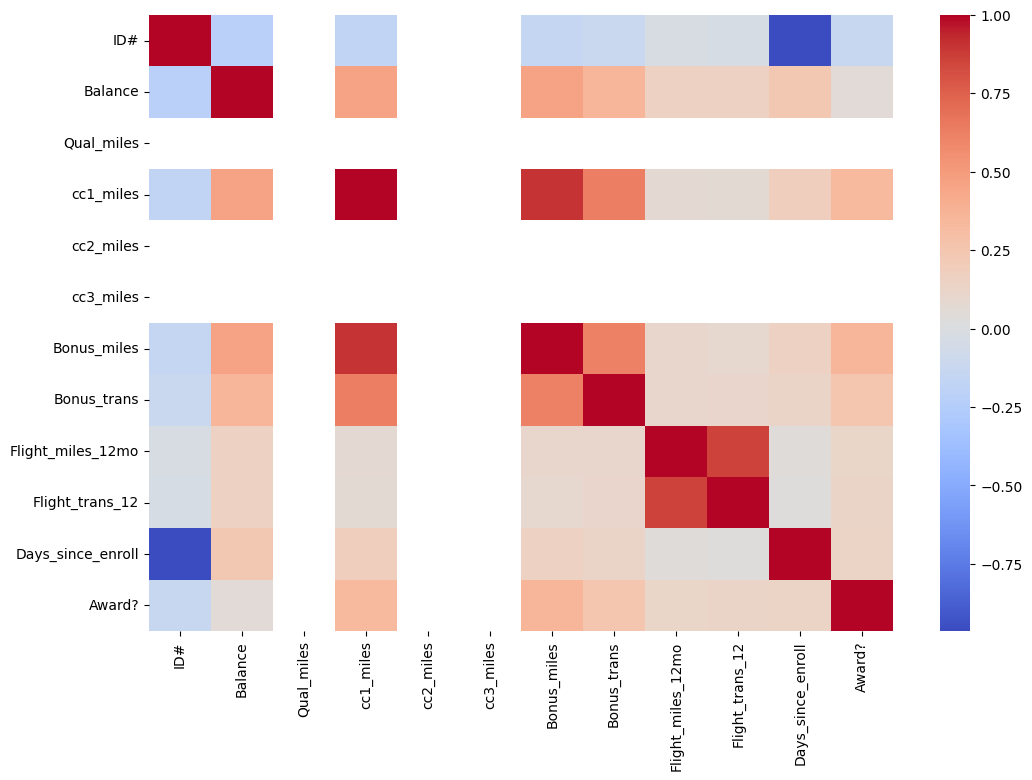

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df_no_outliers.corr(), cmap="coolwarm", annot=False)
plt.show()


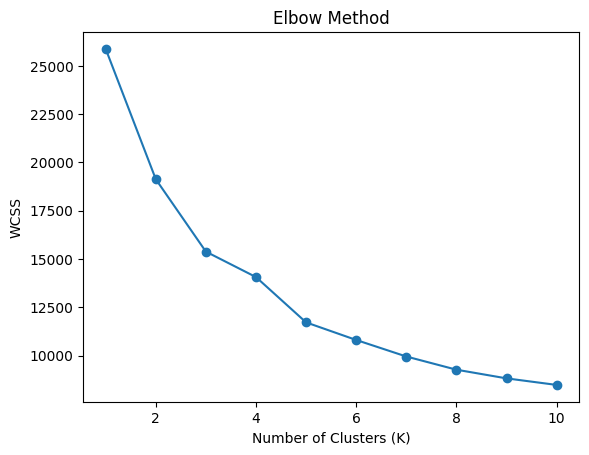

In [13]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [14]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)


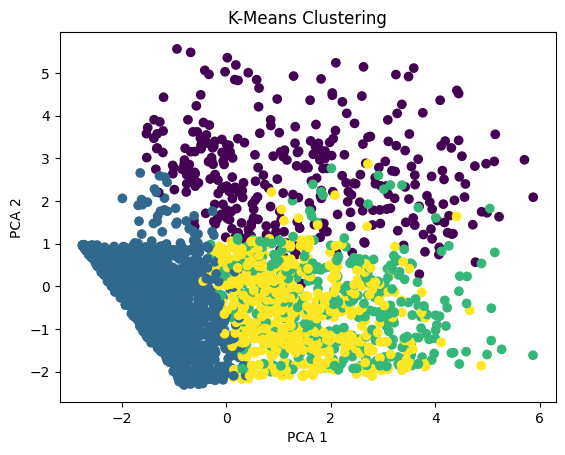

In [15]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels, cmap='viridis')
plt.title("K-Means Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


### Scatter plot Interpretation

**What we see in the plot**

The data points are divided into 4 clusters (different colors)

Clusters are formed based on distance to centroids

Some regions show clear separation, while others overlap

**Interpretation**

K-Means successfully grouped customers with similar travel and loyalty behaviors

Clusters appear compact near the center, which indicates good centroid-based grouping

Overlapping regions suggest customers with mixed behavior patterns

K-Means assumes spherical clusters, which explains why boundaries are not perfectly aligned with data shape

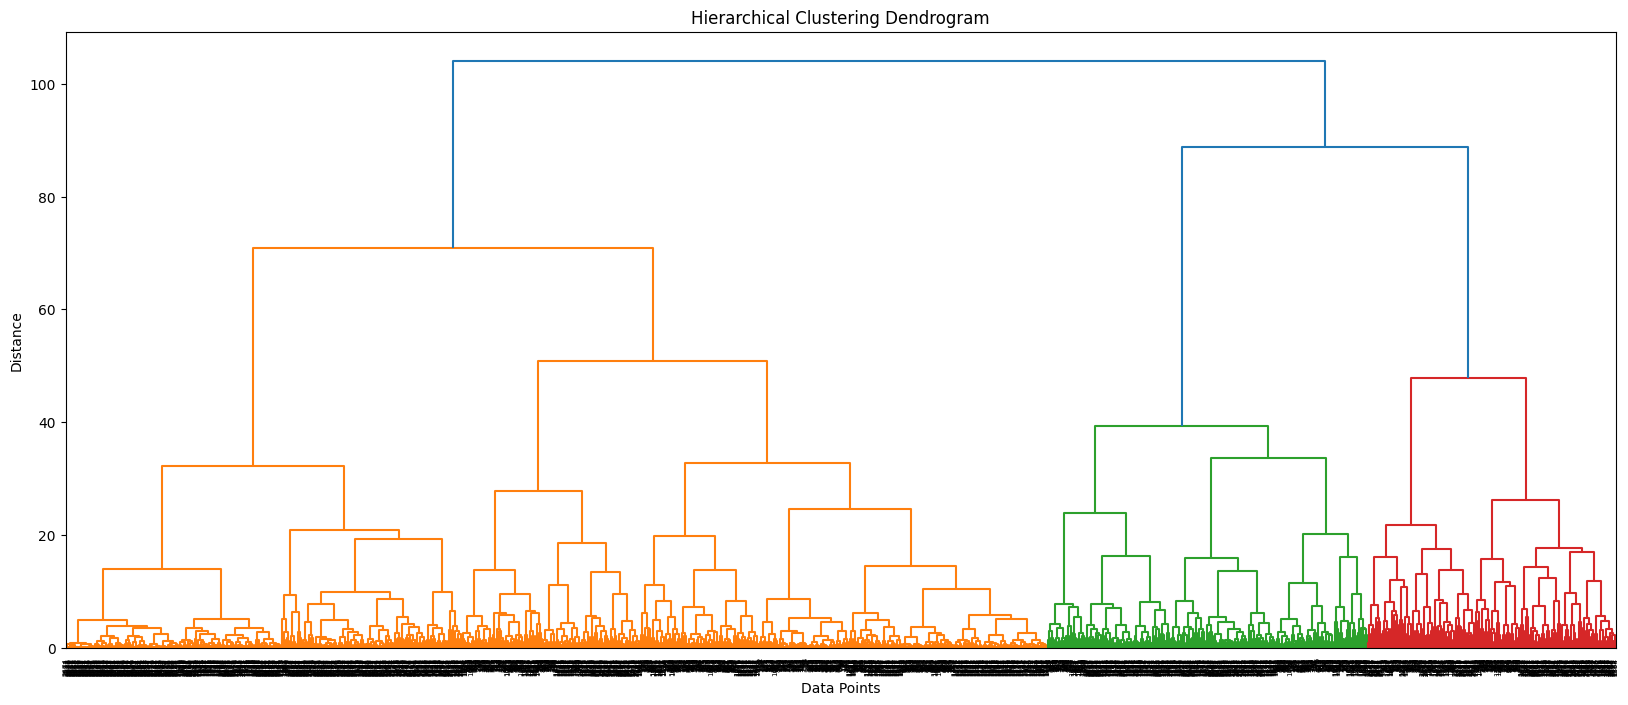

In [25]:
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(20,8))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


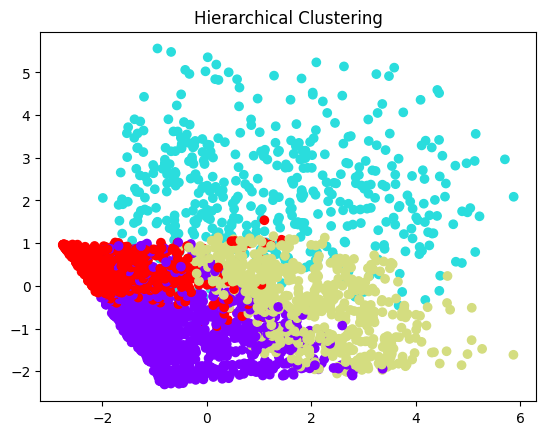

In [17]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
hc_labels = hc.fit_predict(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=hc_labels, cmap='rainbow')
plt.title("Hierarchical Clustering")
plt.show()


### Scatter plot Interpretation

**What we see in the plot**

The data is divided into 4 hierarchical clusters

Cluster boundaries appear more flexible compared to K-Means

Some clusters capture gradual transitions in the data

**Interpretation**

Hierarchical clustering captures nested relationships among customers

Unlike K-Means, it does not rely on centroids, leading to more natural-shaped clusters

The overlap indicates incremental differences in customer behavior rather than sharp divisions

Useful for understanding customer hierarchy (low → medium → high engagement)

In [18]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)


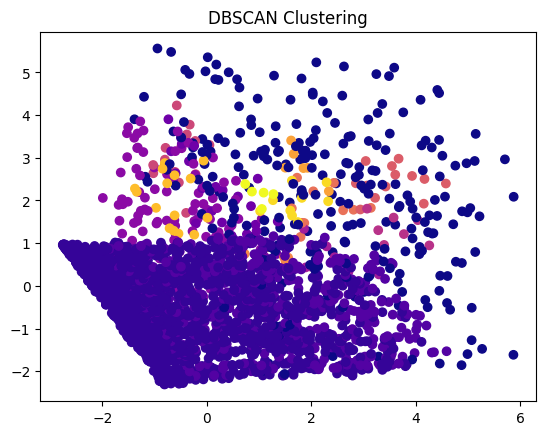

In [19]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=dbscan_labels, cmap='plasma')
plt.title("DBSCAN Clustering")
plt.show()


### Scatter plot interpretation

**What we see in the plot**

One large dense cluster dominates

Several small clusters and scattered points are visible

Some points represent noise or outliers

**Interpretation**

DBSCAN groups customers based on density

Most customers fall into one dense group, indicating similar usage patterns

Sparse points represent rare or unusual customer behaviors

DBSCAN struggles because the dataset has varying densities and high dimensionality

In [20]:
from sklearn.metrics import silhouette_score


In [21]:
# K-Means silhouette score
kmeans_silhouette = silhouette_score(scaled_data, kmeans_labels)
print("Silhouette Score for K-Means:", kmeans_silhouette)


Silhouette Score for K-Means: 0.28357826594485636


In [26]:
mask = dbscan_labels != -1
filtered_data = scaled_data[mask]
filtered_labels = dbscan_labels[mask]


In [23]:
# DBSCAN silhouette score
if len(set(filtered_labels)) > 1:
    dbscan_silhouette = silhouette_score(filtered_data, filtered_labels)
    print("Silhouette Score for DBSCAN:", dbscan_silhouette)
else:
    print("DBSCAN produced only one cluster. Silhouette score not applicable.")


Silhouette Score for DBSCAN: 0.10413864869243707
